# Data Loading & Splitting

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Path to dataset (your extracted Tiger.zip folder)
data_dir = "E:\\Dev\\Deep Datasets\\Tiger"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load dataset from train, valid, test directories
train_ds = image_dataset_from_directory(
    f"{data_dir}\\train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42
)

val_ds = image_dataset_from_directory(
    f"{data_dir}\\valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42
)

test_ds = image_dataset_from_directory(
    f"{data_dir}\\test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42
)

Found 100 files belonging to 1 classes.


Found 100 files belonging to 1 classes.
Found 100 files belonging to 1 classes.


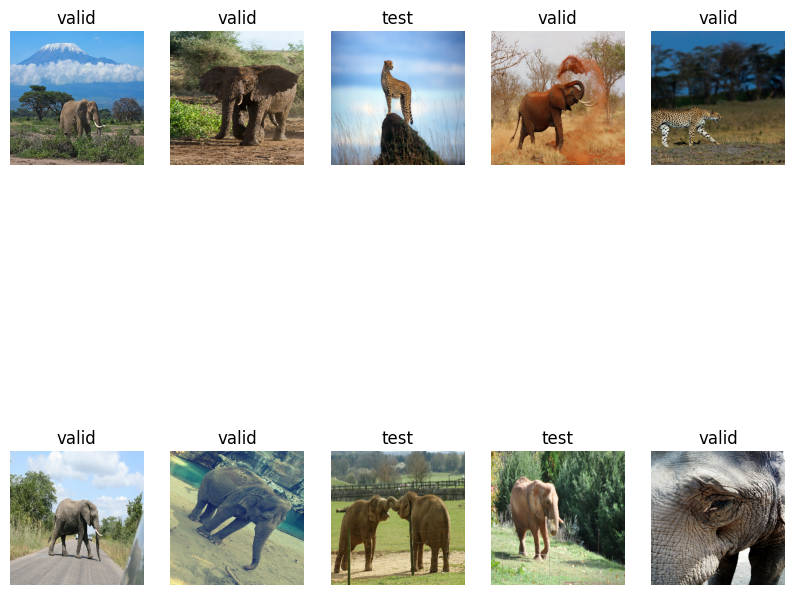

In [ ]:
class_names = train_ds.class_names

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(10):  # adjust for classes
        ax = plt.subplot(2,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

In [ ]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

In [6]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras import layers, models

base_model = MobileNet(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.8000 - loss: 0.4113 - val_accuracy: 1.0000 - val_loss: 5.3748e-05
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 1.0000 - loss: 6.5648e-04 - val_accuracy: 1.0000 - val_loss: 7.0453e-07
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 1.0000 - loss: 7.7910e-06 - val_accuracy: 1.0000 - val_loss: 3.4571e-08
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 1.0000 - loss: 3.3912e-06 - val_accuracy: 1.0000 - val_loss: 4.7684e-09
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 1.0000 - loss: 1.1086e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


Text(0.5, 1.0, 'Loss')

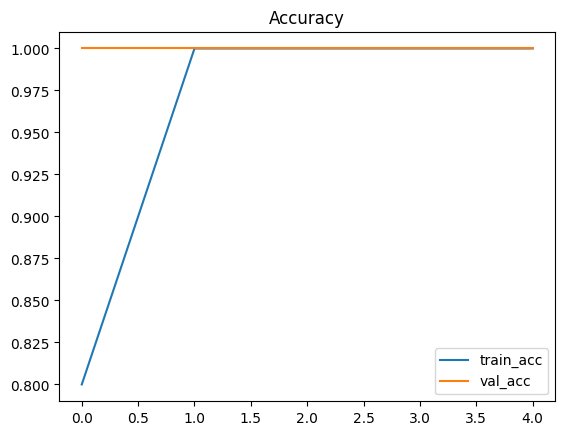

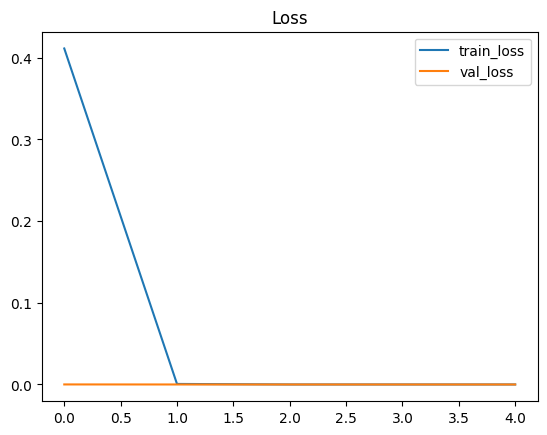

In [12]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")

plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")

In [13]:
for images, labels in test_ds.take(1):
    preds = model.predict(images)

    for i in range(5):
        pred_class = class_names[np.argmax(preds[i])]
        true_class = class_names[labels[i]]
        confidence = np.max(preds[i]) * 100

        print(f"Image {i+1}: Predicted = {pred_class} ({confidence:.2f}%), Ground Truth = {true_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Image 1: Predicted = test (100.00%), Ground Truth = test
Image 2: Predicted = test (100.00%), Ground Truth = test
Image 3: Predicted = test (100.00%), Ground Truth = test
Image 4: Predicted = test (100.00%), Ground Truth = test
Image 5: Predicted = test (100.00%), Ground Truth = test


In [14]:
model.save('wildlife_mobilenet_model.keras')
print('Model saved to wildlife_mobilenet_model.keras')

Model saved to wildlife_mobilenet_model.keras
